# The code behind it: build the CI & its coverage demo

*Part 2 · Lesson 12 · the code behind it  ·  data: Ames, Iowa housing (same as Lesson 12)*

*↩ A companion to [Lesson 12: What a 95% confidence interval really means](12-confidence-intervals.ipynb).*

**↩ Back:** [Flagship — Confidence intervals](12-confidence-intervals.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](12-confidence-intervals~another-dataset.ipynb)

**The flagship lesson *proved* what "95% confidence" means** by simulation: it treated the whole Ames file as
a population with a known true mean μ, built 100 confidence intervals from random samples, and counted how
many caught μ — about 95. It leaned on a helper called `confidence_interval(...)` and a `coverage(...)` loop
that were handed to you ready-made.

This companion **opens the hood on both**. You'll build the 95% CI yourself, *from the formula*, and check it
against SciPy to the decimal. Then you'll write the coverage simulation from scratch — first as a plain,
readable loop, then as the fast vectorized idiom — and watch the headline number, **~95**, fall out of your
own code. By the end, the magic helper is just a function you could write from memory.

Same data, same true mean, same iconic picture — but the focus shifts from *what the 95% means* to **how you
compute it in Python**. We'll go in the order a programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load Ames, treat the whole column as the population, read off the true mean μ.
3. **Build it step by step** — turn the $\bar{x} \pm t^{*}\,s/\sqrt{n}$ formula into code, check it against `scipy.stats`.
4. **The idiom** — the coverage simulation as a loop, then the same thing vectorized over an array of samples.
5. **Refactor into functions** — wrap it as `ci(...)` and `coverage(...)`, then reuse them everywhere.
6. **Now you code** — predict-then-run exercises.
7. **What you learned** — the coding *and* the statistics.

You don't need the flagship fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have written two functions:

- `ci(sample, conf=0.95)` → the low and high ends of a confidence interval, built straight from the formula.
- `coverage(pop, n, reps, conf, rng)` → the fraction of `reps` intervals that capture the true mean.

With those two pieces you can reproduce the entire flagship result yourself: the single interval, the
**~95% coverage**, the caterpillar picture, the confidence-level sweep, and the subtle reason we use a
**t**-multiplier instead of a fixed `1.96`. Nothing here needs new statistics — it's the Python *underneath*
the helper the flagship handed you.

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **NumPy** | fast math on whole arrays at once | the formula, and drawing thousands of samples |
| **SciPy** (`scipy.stats`) | a library of distributions | the t-multiplier `t.ppf`, and a ready-made `t.interval` to check against |
| **pandas** | tables (`DataFrame`) | loading the CSV and a tidy results table |
| **matplotlib** | plotting | the iconic caterpillar plot of 100 intervals |

The one idea that makes this whole demo *possible*: we treat the **entire file** as the population. That's a
choice — it models the data as one draw from an i.i.d. "super-population" of homes — and it's what lets us
**know the true mean μ**, so we can check whether each interval actually caught it.

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)
print(f'Loaded a {type(ames).__name__} with shape {ames.shape}  (rows, columns)')

Loaded a DataFrame with shape (2930, 82)  (rows, columns)


## 2) The data in code

The flagship's variable is **living area (sq ft)** — deliberately right-skewed, to show the magic works even
when the data is *not* a tidy bell curve. We mirror it exactly: pull out the `area` column, drop any holes,
and turn it into a plain NumPy array.

The crucial move is the next one: **the whole column *is* the population.** So its mean is the *true* mean μ —
not an estimate, the actual answer we'll spend the rest of the notebook trying to catch.

In [2]:
population = ames['area'].dropna().to_numpy()    # treat the WHOLE file as the population
MU = population.mean()                           # the TRUE mean (we get to know it!)
SIGMA = population.std(ddof=0)                    # the TRUE population standard deviation
N_POP = len(population)

print(f'Population: {N_POP:,} homes')
print(f'TRUE population mean  MU    = {MU:.1f} sq ft   <- the answer we will try to catch')
print(f'TRUE population stdev SIGMA = {SIGMA:.1f} sq ft')
print(f'\nfirst 5 areas: {population[:5]}')

Population: 2,930 homes
TRUE population mean  MU    = 1499.7 sq ft   <- the answer we will try to catch
TRUE population stdev SIGMA = 505.4 sq ft

first 5 areas: [1656  896 1329 2110 1629]


### Sampling with replacement

When we draw a sample, we'll use `rng.choice(population, size=n, replace=True)` — drawing **with
replacement**. That treats the file as an i.i.d. super-population (each draw is independent, the same home
*could* in principle come up twice), which is the clean textbook setting the t-interval is built for. Because
`n` is tiny next to `N_POP`, it barely differs from sampling without replacement anyway.

And one rule for the whole notebook: **every** random draw comes from one seeded generator,
`rng = np.random.default_rng(0)`. Seeding means you'll see the *exact same numbers* this text quotes, and your
results are reproducible. Never reach for unseeded `np.random.*`.

In [3]:
rng = np.random.default_rng(0)   # the ONE generator we seed; reused everywhere below
n = 50                           # our sample size

sample = rng.choice(population, size=n, replace=True)
print(f'A sample of n = {n} homes (sq ft):')
print(np.round(sample[:10], 0), '...')
print(f'\nsample mean   = {sample.mean():.1f} sq ft')
print(f'true mean MU  = {MU:.1f} sq ft   <- the sample mean misses it a little; that wobble is the whole story')

A sample of n = 50 homes (sq ft):
[ 925 1295 3820 1276  960 1209  912 1752 2490 2076] ...

sample mean   = 1502.2 sq ft
true mean MU  = 1499.7 sq ft   <- the sample mean misses it a little; that wobble is the whole story


## 3) Build it step by step

Now the heart of it. The 95% confidence interval for a mean is one formula:

$$\bar{x} \;\pm\; t^{*}\cdot \frac{s}{\sqrt{n}}$$

- $\bar{x}$ — the **sample** mean (our estimate of μ): `sample.mean()`.
- $s$ — the sample standard deviation, with the $n-1$ divisor: `sample.std(ddof=1)`.
- $s/\sqrt{n}$ — the **standard error** (SE): how much $\bar{x}$ wobbles from sample to sample.
- $t^{*}$ — the multiplier (about 2 for 95%) from the *t-distribution*: `stats.t.ppf(0.975, df=n-1)`.

We'll write each piece, assemble the interval, and check it against SciPy's ready-made `stats.t.interval`.

In [4]:
xbar = sample.mean()
s    = sample.std(ddof=1)          # ddof=1 -> divide by n-1 (the SAMPLE standard deviation)
se   = s / np.sqrt(n)              # the standard error
tstar = stats.t.ppf(0.975, df=n - 1)   # the t-multiplier for 95% (two tails -> 0.975 in each)

lo = xbar - tstar * se
hi = xbar + tstar * se

print(f'xbar (sample mean)   = {xbar:.2f} sq ft')
print(f's    (sample SD)      = {s:.2f} sq ft   (ddof=1: divide by n-1, the sample SD)')
print(f'se   = s/sqrt(n)      = {se:.2f} sq ft')
print(f'tstar = t.ppf(.975)   = {tstar:.4f}   (df = n-1 = {n-1})')
print(f'\n95% CI = ({lo:.1f}, {hi:.1f}) sq ft')
print(f'true mean MU = {MU:.1f} -> caught? {lo <= MU <= hi}')

xbar (sample mean)   = 1502.16 sq ft
s    (sample SD)      = 613.06 sq ft   (ddof=1: divide by n-1, the sample SD)
se   = s/sqrt(n)      = 86.70 sq ft
tstar = t.ppf(.975)   = 2.0096   (df = n-1 = 49)

95% CI = (1327.9, 1676.4) sq ft
true mean MU = 1499.7 -> caught? True


**What is `tstar`, in one friendly line?** It's the "how many standard errors wide" number: to leave 2.5% of
the t-distribution in each tail (95% in the middle), you reach out about `tstar` SEs from the sample mean —
roughly 2, a touch more for small samples.

Now the check that matters. SciPy's `stats.t.interval(0.95, df=n-1, loc=xbar, scale=se)` computes the *same*
interval its own way. If our hand-built formula is right, the two must agree to the last decimal.

In [5]:
lo_scipy, hi_scipy = stats.t.interval(0.95, df=n - 1, loc=xbar, scale=se)

print(f'our formula : ({lo:.6f}, {hi:.6f})')
print(f'scipy       : ({lo_scipy:.6f}, {hi_scipy:.6f})')
print('match?', np.isclose(lo, lo_scipy) and np.isclose(hi, hi_scipy))

our formula : (1327.928861, 1676.391139)
scipy       : (1327.928861, 1676.391139)
match? True


## 4) The idiom — the coverage simulation, loop then vectorized

One interval either catches μ or it doesn't — that's luck. The real claim of "95% confidence" is about the
**long run**: if you repeated the whole process many times, about 95% of the intervals would contain μ.

So the simulation is: **draw a sample, build its CI, ask "did it catch μ?", repeat — and count.**

### First, the clear way: an explicit loop

Easiest to read: loop `reps` times, build one CI per pass, tally the hits. We keep `reps` at 10,000 so it
runs in a blink.

In [6]:
reps = 10_000
hits = 0
for _ in range(reps):
    samp = rng.choice(population, size=n, replace=True)
    xb = samp.mean()
    se_i = samp.std(ddof=1) / np.sqrt(n)
    lo_i = xb - tstar * se_i
    hi_i = xb + tstar * se_i
    if lo_i <= MU <= hi_i:        # did THIS interval catch the true mean?
        hits += 1

print(f'{hits:,} of {reps:,} intervals caught the true mean.')
print(f'Coverage (loop) = {hits / reps * 100:.1f}%   <- the headline: the theory predicts ~95%')

9,486 of 10,000 intervals caught the true mean.


Coverage (loop) = 94.9%   <- the headline: the theory predicts ~95%


### Now the idiom: vectorize over a `(reps, n)` array

The loop is clear but does one sample at a time. NumPy's idiom is to draw **all** the samples at once into a
`(reps, n)` array — `reps` rows, each row a sample of `n` homes — then compute every sample mean and SD in a
single call with `axis=1` (meaning "across each row"). No Python loop, far faster, same answer.

In [7]:
samples = rng.choice(population, size=(reps, n), replace=True)   # reps rows, each a sample of n

xbars = samples.mean(axis=1)                 # one mean per row -> array of length reps
ses   = samples.std(axis=1, ddof=1) / np.sqrt(n)
los   = xbars - tstar * ses
his   = xbars + tstar * ses

caught = (los <= MU) & (MU <= his)           # a True/False array: did each interval catch MU?
coverage_vec = caught.mean()                 # mean of True/False = the FRACTION that are True

print(f'samples array shape : {samples.shape}  (reps, n)')
print(f'caught is a {caught.dtype} array of length {len(caught):,}')
print(f'Coverage (vectorized) = {coverage_vec * 100:.1f}%   <- matches the loop, computed in one shot')

samples array shape : (10000, 50)  (reps, n)
caught is a bool array of length 10,000
Coverage (vectorized) = 94.9%   <- matches the loop, computed in one shot


### Picture it — the iconic "caterpillar" plot

Numbers are convincing; the picture is unforgettable. We draw a fresh batch of **100** intervals as horizontal
lines with `ax.hlines` — **solid teal** when they catch μ, **dashed orange-red (✕)** when they miss — plus a
vertical line at the true mean μ. Encoding the misses by shape *and* colour keeps them visible in grayscale and
for colourblind readers; those ~5% that fail aren't bugs, just the expected price of sampling.

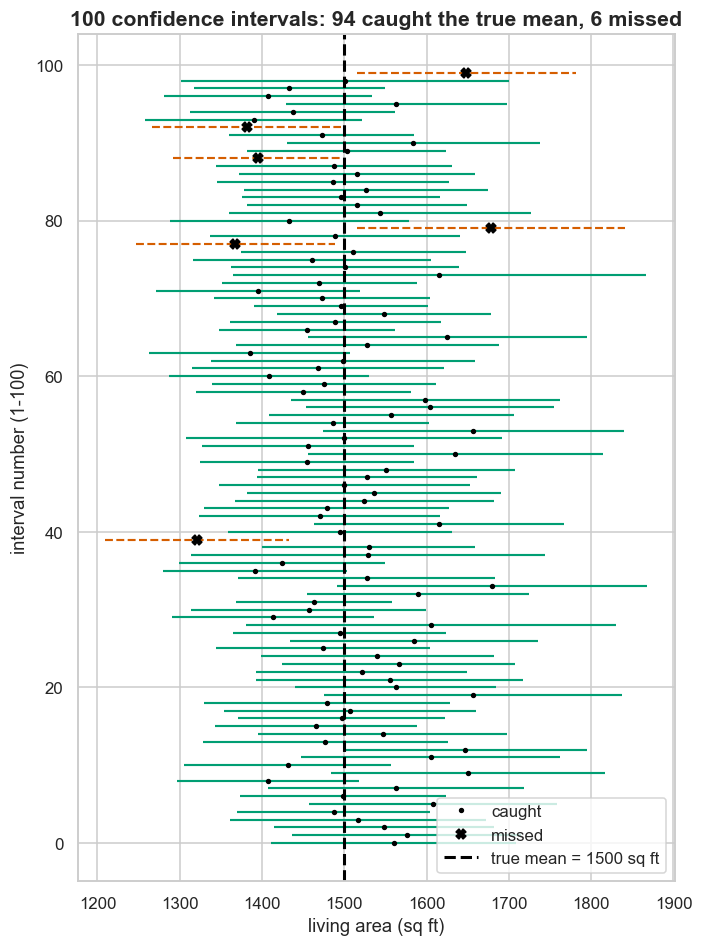

94 of 100 captured the true mean.


In [8]:
k_show = 100
samp100 = rng.choice(population, size=(k_show, n), replace=True)
xb100 = samp100.mean(axis=1)
se100 = samp100.std(axis=1, ddof=1) / np.sqrt(n)
lo100 = xb100 - tstar * se100
hi100 = xb100 + tstar * se100
caught100 = (lo100 <= MU) & (MU <= hi100)
k_caught = int(caught100.sum())

# Encode caught/missed by COLOUR and by LINESTYLE + MARKER, so the picture
# survives grayscale printing and red-green colour-vision deficiency.
colors = np.where(caught100, sl.CAPTURE, sl.MISS)      # teal if caught, vermillion if missed
lstyles = np.where(caught100, '-', '--')               # solid if caught, dashed if missed
ys = np.arange(k_show)

fig, ax = plt.subplots(figsize=(7, 10))
ax.hlines(ys, lo100, hi100, colors=colors, linestyles=lstyles, lw=1.4)   # one line per interval
ax.plot(xb100[caught100], ys[caught100], 'o', color='black', ms=2.5, ls='none', label='caught')
ax.plot(xb100[~caught100], ys[~caught100], 'X', color='black', ms=6, ls='none', label='missed')
ax.axvline(MU, color='black', ls='--', lw=2, label=f'true mean = {MU:.0f} sq ft')
ax.set_xlabel('living area (sq ft)'); ax.set_ylabel('interval number (1-100)')
ax.set_title(f'100 confidence intervals: {k_caught} caught the true mean, {k_show - k_caught} missed')
ax.legend(loc='lower right'); plt.show()

print(f'{k_caught} of {k_show} captured the true mean.')

### The confidence-level sweep — coverage tracks the promise, width grows

Crank the confidence level up and two things should happen together: the **empirical coverage** climbs toward
the higher promise (80% method covers ~80%, 99% method covers ~99%), *and* the interval gets **wider** —
being more sure costs precision. We measure both at each level on the same vectorized batch of samples.

In [9]:
sweep = rng.choice(population, size=(reps, n), replace=True)   # one batch, reused at every level
xb_s = sweep.mean(axis=1)
se_s = sweep.std(axis=1, ddof=1) / np.sqrt(n)

rows = []
for conf in (0.80, 0.90, 0.95, 0.99):
    tstar_c = stats.t.ppf(1 - (1 - conf) / 2, df=n - 1)
    lo_s = xb_s - tstar_c * se_s
    hi_s = xb_s + tstar_c * se_s
    cov = ((lo_s <= MU) & (MU <= hi_s)).mean() * 100
    rows.append({'conf': f'{int(conf*100)}%', 'tstar': round(tstar_c, 3),
                 'coverage_%': round(cov, 1), 'avg_width_sqft': round((hi_s - lo_s).mean(), 1)})

sweep_table = pd.DataFrame(rows)
print(sweep_table.to_string(index=False))
print('\nCoverage tracks the nominal level (left to right ~80/90/95/99), and width grows with it.')

conf  tstar  coverage_%  avg_width_sqft
 80%  1.299        79.5           183.4
 90%  1.677        89.3           236.7
 95%  2.010        94.4           283.7
 99%  2.680        98.7           378.4

Coverage tracks the nominal level (left to right ~80/90/95/99), and width grows with it.


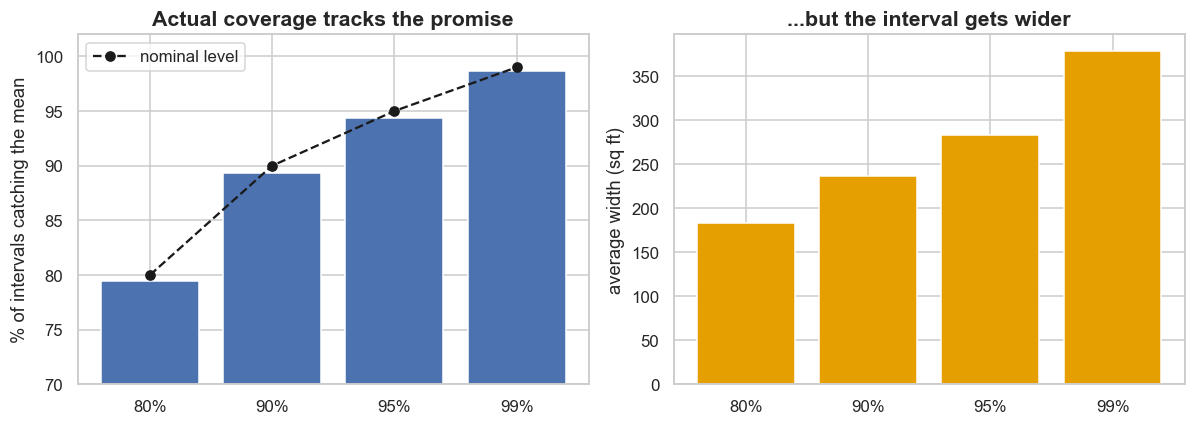

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
nominal = [80, 90, 95, 99]
a1.bar(sweep_table['conf'], sweep_table['coverage_%'], color='#4c72b0')
a1.plot(range(4), nominal, 'k--o', label='nominal level')
a1.set_title('Actual coverage tracks the promise'); a1.set_ylabel('% of intervals catching the mean')
a1.set_ylim(70, 102); a1.legend()
a2.bar(sweep_table['conf'], sweep_table['avg_width_sqft'], color='#E69F00')
a2.set_title('...but the interval gets wider'); a2.set_ylabel('average width (sq ft)')
plt.tight_layout(); plt.show()

### z vs t — why the multiplier isn't just `1.96`

You may have seen `1.96` as "the" 95% multiplier. That's the **z** value, from the normal curve — correct only
if you *knew* the true SD. We estimate it from the sample with `s`, which adds a little extra uncertainty, so
the honest multiplier comes from the **t-distribution** and is slightly *bigger* — making the interval a touch
**wider**. That extra width is exactly what keeps coverage honest, and it matters most at **small `n`**, where
`t` and `z` diverge the most. Let's see both the multipliers and what happens to coverage if you (wrongly) use `z`.

In [11]:
zstar = stats.norm.ppf(0.975)             # 1.96 — the normal multiplier
print(f'z* (normal)        = {zstar:.4f}')
print(f't* (df = n-1 = {n-1}) = {tstar:.4f}   <- a bit bigger, so the t-interval is wider')

# Coverage of the SAME samples using z* instead of t* (re-use the vectorized batch from before):
lo_z = xbars - zstar * ses
hi_z = xbars + zstar * ses
cov_z = ((lo_z <= MU) & (MU <= hi_z)).mean() * 100
print(f'\nCoverage with t* : {coverage_vec * 100:.1f}%   (honest ~95%)')
print(f'Coverage with z* : {cov_z:.1f}%   (a hair UNDER 95% -- the too-narrow interval misses slightly more)')

# The gap is small at n=50 but blows up at tiny n:
print('\nHow much wider is t* than z*, as n shrinks?')
for nn in (5, 10, 30, 50, 200):
    t_nn = stats.t.ppf(0.975, df=nn - 1)
    print(f'  n = {nn:>3}:  t* = {t_nn:.3f}  vs  z* = {zstar:.3f}   (t* is {(t_nn/zstar - 1)*100:4.1f}% bigger)')

z* (normal)        = 1.9600
t* (df = n-1 = 49) = 2.0096   <- a bit bigger, so the t-interval is wider

Coverage with t* : 94.9%   (honest ~95%)
Coverage with z* : 94.3%   (a hair UNDER 95% -- the too-narrow interval misses slightly more)

How much wider is t* than z*, as n shrinks?
  n =   5:  t* = 2.776  vs  z* = 1.960   (t* is 41.7% bigger)
  n =  10:  t* = 2.262  vs  z* = 1.960   (t* is 15.4% bigger)
  n =  30:  t* = 2.045  vs  z* = 1.960   (t* is  4.4% bigger)
  n =  50:  t* = 2.010  vs  z* = 1.960   (t* is  2.5% bigger)
  n = 200:  t* = 1.972  vs  z* = 1.960   (t* is  0.6% bigger)


## 5) Refactor into reusable functions

We've now written the CI formula and the coverage loop a few times. The programmer's reflex is to **wrap
repeated work in a function**. Two functions capture everything:

- `ci(sample, conf=0.95)` → `(lo, hi)` — the interval from one sample.
- `coverage(pop, n, reps, conf, rng)` → the fraction of intervals that capture the true mean.

Once they're correct, the whole flagship demo becomes a couple of clean calls — and we can rerun the
confidence-level sweep through them with no copy-pasted formulas.

In [12]:
def ci(sample, conf=0.95):
    '''Return (lo, hi): the confidence interval for the mean of one sample.'''
    sample = np.asarray(sample)
    m = len(sample)
    xb = sample.mean()
    se_ = sample.std(ddof=1) / np.sqrt(m)
    tcrit = stats.t.ppf(1 - (1 - conf) / 2, df=m - 1)
    return xb - tcrit * se_, xb + tcrit * se_


def coverage(pop, n, reps, conf, rng):
    '''Fraction of `reps` confidence intervals (each from a fresh sample of size n) that capture the true mean.'''
    mu = pop.mean()
    samples = rng.choice(pop, size=(reps, n), replace=True)
    xbars_ = samples.mean(axis=1)
    ses_ = samples.std(axis=1, ddof=1) / np.sqrt(n)
    tcrit = stats.t.ppf(1 - (1 - conf) / 2, df=n - 1)
    los_ = xbars_ - tcrit * ses_
    his_ = xbars_ + tcrit * ses_
    return ((los_ <= mu) & (mu <= his_)).mean()


# Check ci() against our Section-3 numbers and against SciPy on the original sample:
lo_f, hi_f = ci(sample, conf=0.95)
lo_chk, hi_chk = stats.t.interval(0.95, df=n - 1, loc=sample.mean(), scale=sample.std(ddof=1) / np.sqrt(n))
print(f'ci(sample)        = ({lo_f:.4f}, {hi_f:.4f})')
print(f'scipy t.interval  = ({lo_chk:.4f}, {hi_chk:.4f})')
print('match?', np.isclose(lo_f, lo_chk) and np.isclose(hi_f, hi_chk))

# Reuse coverage() to redo the whole sweep in three lines:
print('\nConfidence-level sweep, via the reusable coverage():')
for conf in (0.80, 0.90, 0.95, 0.99):
    cov = coverage(population, n=50, reps=10_000, conf=conf, rng=rng) * 100
    print(f'  {int(conf*100)}% method -> {cov:.1f}% coverage')

ci(sample)        = (1327.9289, 1676.3911)
scipy t.interval  = (1327.9289, 1676.3911)
match? True

Confidence-level sweep, via the reusable coverage():
  80% method -> 79.5% coverage
  90% method -> 89.3% coverage
  95% method -> 95.1% coverage
  99% method -> 98.5% coverage


Two functions, and the flagship is yours: `ci` turns a sample into an interval, `coverage` turns the whole
simulation into one number. Once they're correct you stop thinking about `t.ppf` and `ddof=1` and start
thinking in **samples, intervals, and hit rates** — the leap from "writing statistics" to "doing statistics
in code." (And yes, `scipy.stats.t.interval` exists; the point was to *build* it so you know what it's doing.)

## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — **predict the answer
before you run it.**

1. **Bigger sample, narrower net.** Call `coverage(population, n=200, reps=10_000, conf=0.95, rng=rng)`.
   Predict first: does the *coverage* change much from the n = 50 value (~95%)? Then build one interval with
   `ci(rng.choice(population, size=200, replace=True))` and compare its **width** to the n = 50 interval from
   Section 3 — which is narrower, and why? (Hint: the $\sqrt{n}$ in the standard error.)

2. **The seed changes the picture, not the rate.** Re-run the caterpillar cell with a *different* generator,
   `rng2 = np.random.default_rng(1)`, drawing the 100 samples from `rng2`. Predict: will roughly the same
   *number* of 100 be captured (~95), even though the specific green/red pattern is different?

3. **Confirm z gives a narrower interval.** For the Section-3 `sample`, build the interval two ways — with
   `tstar = stats.t.ppf(0.975, df=n-1)` and with `zstar = stats.norm.ppf(0.975)` (= 1.96) — and print both
   widths. Which is wider? By how many sq ft? (The t one should be a touch wider — that's the honesty premium.)

4. **A different variable.** Swap in sale price: `pop2 = ames['price'].dropna().to_numpy()`. Run
   `coverage(pop2, n=50, reps=10_000, conf=0.95, rng=rng)`. Price is *more* skewed than living area — does the
   95% method still cover close to 95% at n = 50? (It should be close, a hair under — the Central Limit
   Theorem at work.)

## What you learned

**Coding**
- The 95% CI is four short lines: `xbar`, `s = sample.std(ddof=1)`, `se = s/np.sqrt(n)`, and
  `tstar = stats.t.ppf(0.975, df=n-1)`, then `xbar ± tstar*se`. You checked it against `stats.t.interval` —
  **match? True**.
- A whole **simulation** is "draw, build, check, repeat, count." Written first as an explicit `for` loop, then
  as the NumPy **idiom**: draw a `(reps, n)` array, reduce with `.mean(axis=1)` / `.std(axis=1, ddof=1)`, and
  let the **mean of a True/False array** be the coverage fraction.
- `ax.hlines(ys, lo, hi, colors=..., linestyles=...)` draws the caterpillar plot; a boolean array picks both the
  colour (teal vs. vermillion) and the linestyle/marker, so "miss" reads without relying on colour alone.
- **Refactor repeated work into functions** (`ci`, `coverage`) with clear inputs and a `return`, then reuse them.
- **Seed every random draw** (`rng = np.random.default_rng(0)`) so results are reproducible.

**Statistics (now demystified)**
- A confidence interval is an estimate **±** a multiplier times the **standard error** $s/\sqrt{n}$; the
  multiplier `tstar` comes from the **t-distribution** with `df = n-1`.
- "95% confidence" is the **method's long-run hit rate** — your own loop produced **~95%** coverage, and the
  caterpillar plot showed ~95 of 100 intervals catching μ.
- The sweep showed empirical coverage **tracks the nominal level** (80/90/95/99%) while the interval **gets
  wider** — the more-sure-vs-more-precise trade-off.
- We use **t**, not the fixed **z = 1.96**, because we estimate the SD from the sample; `tstar > zstar` makes
  the interval slightly wider and **keeps coverage honest**, most noticeably at small `n`.

**Back to the core lesson** ([Lesson 12: What a 95% confidence interval really means](12-confidence-intervals.ipynb))
for the *meaning* of these numbers, or read on through the course.

---

**↩ Back to the lesson:** [Flagship — Confidence intervals](12-confidence-intervals.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](12-confidence-intervals~another-dataset.ipynb)